In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
from pathlib import Path
from functools import reduce

In [3]:
# Enter data path
data_path = "/Users/sana/Downloads/STAT390/Data/All Calls by Month"


In [5]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))

In [7]:
## loading in all all calls data 

i=0; df = []
for f in files:
    if f.suffix.lower() == ".csv":
        df.append(pd.read_csv(f, header=0, dtype=str, engine="python", skip_blank_lines=False, nrows = 5))
    else:  # .xlsx
        df.append(pd.read_excel(f, sheet_name=0, header=0, dtype=str, nrows = 5))
    #df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df[i].shape)
    i = i + 1

0 April 2024 (5, 63)
1 April 2025 (5, 63)
2 August 2024 (5, 57)
3 August 2025 (5, 63)
4 December 2024 (5, 55)
5 February 2025 (5, 63)
6 January 2025 (5, 64)
7 July 2024 (5, 55)
8 July 2025 (5, 63)
9 June 2024 (5, 63)
10 June 2025 (5, 63)
11 March 2025 (5, 64)
12 May 2024 (5, 63)
13 May 2025 (5, 63)
14 November 2024 (5, 63)
15 October 2024 (5, 55)
16 September 2024 (5, 55)


In [9]:
# columns
all_cols = reduce(lambda x, y: x | set(y.columns), df[1:], set(df[0].columns))
common_cols = reduce(lambda x, y: x & set(y.columns), df[1:], set(df[0].columns))
common_cols
not_in_all = all_cols - common_cols
print("Columns missing from at least one dataframe:", not_in_all)

Columns missing from at least one dataframe: {'Call Recording Trigger', 'External caller ID number', 'Call Recording Platform Name', 'User', 'Redirecting party UUID', 'Public Called IP Address', 'Column1', 'Call Recording Result', 'Public Calling IP Address', 'Device owner UUID', 'PSTN vendor name2'}


In [11]:
print(common_cols)

{'OS type', 'PSTN vendor Org ID', 'Remote SessionID', 'PSTN vendor name', 'Call outcome reason', 'Report ID', 'Outbound trunk', 'Direction', 'Call transfer time', 'Device Mac', 'Call type', 'Inbound trunk', 'Related reason', 'Correlation ID', 'Answer time', 'Redirecting number', 'Release time', 'Site main number', 'Site timezone', 'Original reason', 'User UUID', 'Report time', 'User type', 'Route group', 'Sub client type', 'Location', 'Final local sessionID', 'PSTN legal entity', 'Start time', 'Client version', 'International Country', 'Authorization code', 'PSTN provider ID', 'Related call ID', 'Department ID', 'Answered', 'Redirect reason', 'Ring duration', 'Local call ID', 'Client type', 'Call ID', 'User number', 'Final remote sessionID', 'Duration', 'Site UUID', 'Model', 'Org UUID', 'Remote call ID', 'Called number', 'Network call ID', 'Local SessionID', 'Call outcome', 'Transfer related call ID', 'Releasing party', 'Answer Indicator'}


In [13]:
## combining into one dataset of all calls

df_main = pd.DataFrame(columns=list(common_cols))

In [15]:
i=0; 
for f in files:
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=0, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=0, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)
    i = i + 1

0 April 2024 (56662, 63)
1 April 2025 (63636, 63)
2 August 2024 (63262, 57)
3 August 2025 (57071, 63)
4 December 2024 (49445, 55)
5 February 2025 (63669, 63)
6 January 2025 (62623, 64)
7 July 2024 (62292, 55)
8 July 2025 (60438, 63)
9 June 2024 (56763, 63)
10 June 2025 (54598, 63)
11 March 2025 (59149, 64)
12 May 2024 (62944, 63)
13 May 2025 (55428, 63)
14 November 2024 (49953, 63)
15 October 2024 (62354, 55)
16 September 2024 (61250, 55)


In [17]:
df_main["Start time"] = pd.to_datetime(df_main["Start time"], utc=True)

## all above code is provided by Prof Krishna to import all calls

In [63]:
df_main.head()

,OS type,PSTN vendor Org ID,Remote SessionID,PSTN vendor name,Call outcome reason,Report ID,Outbound trunk,Direction,Call transfer time,Device Mac,...,Device owner UUID,Call Recording Platform Name,Call Recording Result,Call Recording Trigger,Redirecting party UUID,Public Calling IP Address,Public Called IP Address,Column1,PSTN vendor name2,User
0,na,NaN,NaN,CallTower,NaN,8186ffa7-a035-3c77-899b-0d7eb5ecb8d7,wcc_Pc_tp-ipRwm_ku064NHZiw,TERMINATING,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,na,NaN,NaN,CallTower,NaN,3aa785ae-9749-3885-a899-9bbd349b066f,NaN,TERMINATING,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,na,NaN,NaN,NaN,NaN,6d9dabf5-91fe-32d0-9a9c-e58b99c339b6,NaN,TERMINATING,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,na,NaN,79937c83a9384a24868893296fe2c0ea,NaN,NaN,2c741738-f888-3f25-9abc-e791f6911999,NaN,ORIGINATING,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ios,NaN,00000000000000000000000000000000,CallTower,NaN,1ea06a02-8d6e-30b4-893c-20768edcde0b,NaN,ORIGINATING,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
unique_calls = df_main['Called number'].unique()

In [ ]:
## Now looking at popular phone lines

In [117]:
phone_line_total_calls = df_main['Called number'].value_counts().reset_index()
phone_line_total_calls.columns = ['Called number', 'total_calls']

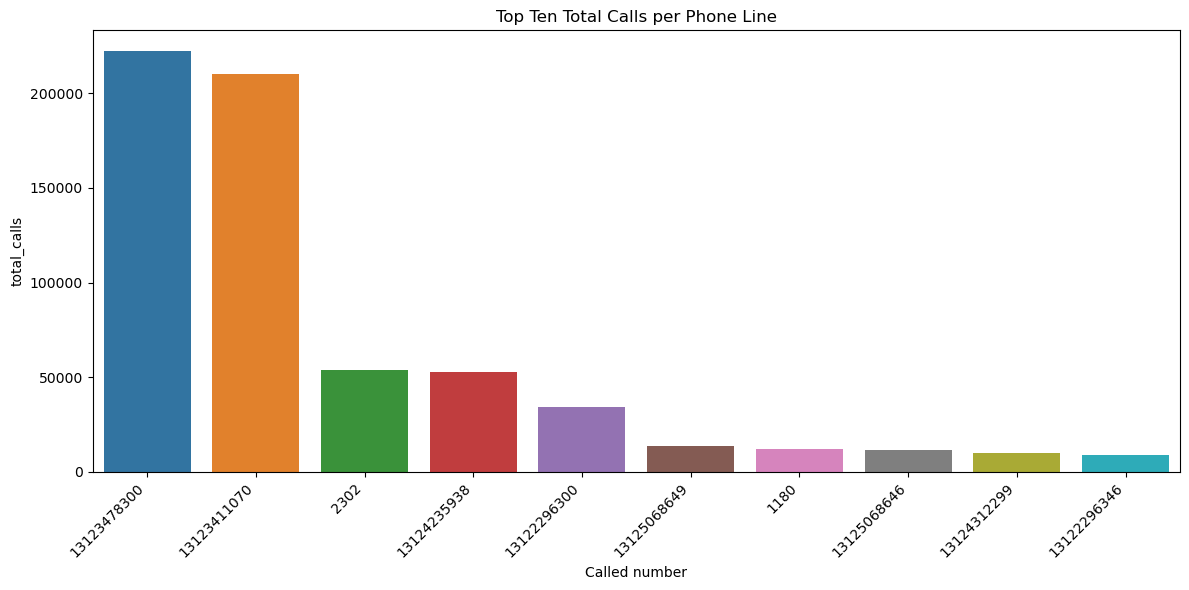

In [119]:
## Looking at top ten popular phone lines

phone_line_total_calls_top_ten = phone_line_total_calls.head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=phone_line_total_calls_top_ten, x='Called number', y='total_calls')
plt.xticks(rotation=45, ha='right')
plt.title('Top Ten Total Calls per Phone Line')
plt.tight_layout()
plt.show()

In [105]:
## Looking at termination reasons by phone line

termination_counts = df_main.groupby(['Called number', 'Call outcome reason']).size().reset_index(name='call_count')
termination_counts['pct'] = termination_counts.groupby('Called number')['call_count'].transform(lambda x: x / x.sum() * 100)


In [107]:
termination_counts

,Called number,Call outcome reason,call_count,pct
0,#,CallRejected,43,91.489362
1,#,UnassignedNumber,4,8.510638
2,#03221003089104#0,Normal,1,100.000000
3,#03221022116927#0,Normal,1,100.000000
4,#03221096229554#0,Normal,1,100.000000
...,...,...,...,...
24022,997735203698,CallRejected,1,100.000000
24023,998002727442,CallRejected,1,100.000000
24024,9999,CallRejected,1,100.000000
24025,99999,CallRejected,1,100.000000


In [ ]:
## Now looking at english and spanish distributions
## recognized number as people calling the Spanish Main Menu: 13125068647
## English Main Menu: 13125068646


In [41]:
# Filter to only inbound (terminating) calls
inbound_df = df_main[df_main['Direction'].str.lower() == 'terminating']

#filter by each main menu number
spanish_calls = inbound_df[inbound_df['Called number'] == '13125068647']
english_calls = inbound_df[inbound_df['Called number'] == '13125068646']

# get counts
print("Spanish main menu calls:", len(spanish_calls))
print("English main menu calls:", len(english_calls))


Spanish main menu calls: 2041
English main menu calls: 5952


In [39]:
# WITHOUT filtering (confirming across Clarifications_on_CAR_&_AllCallsData_6OCT excel sheet numbers)
spanish_calls = df_main[df_main['Called number'] == '13125068647']
english_calls = df_main[df_main['Called number'] == '13125068646']
print("Spanish main menu calls:", len(spanish_calls))
print("English main menu calls:", len(english_calls))

Spanish main menu calls: 4032
English main menu calls: 11632


In [89]:
# Now looking at duration of spanish english calls by pulling all correlation ids of those sessions


# Convert Duration to numeric, forcing invalid values to NaN
df_main['Duration'] = pd.to_numeric(df_main['Duration'], errors='coerce')

spanish_df = inbound_df[inbound_df['Called number'] == '13125068647']
english_df = inbound_df[inbound_df['Called number'] == '13125068646']


In [103]:
cap_seconds = 7200  # 2 hours (outliers were found) 

#  Duration is numeric in the df
spanish_df['Duration'] = pd.to_numeric(spanish_df['Duration'], errors='coerce')
english_df['Duration'] = pd.to_numeric(english_df['Duration'], errors='coerce')

# 2Group by session
spanish_sessions = (
    spanish_df.groupby('Correlation ID')['Duration']
    .sum()
    .reset_index(name='total_duration')
)
english_sessions = (
    english_df.groupby('Correlation ID')['Duration']
    .sum()
    .reset_index(name='total_duration')
)

# Make sure total_duration is numeric (just in case)
spanish_sessions['total_duration'] = pd.to_numeric(spanish_sessions['total_duration'], errors='coerce')
english_sessions['total_duration'] = pd.to_numeric(english_sessions['total_duration'], errors='coerce')

# count how many sessions exceed 2 hours
spanish_over2h = (spanish_sessions['total_duration'] > cap_seconds).sum()
english_over2h = (english_sessions['total_duration'] > cap_seconds).sum()

print(f"Spanish sessions over 2 hours: {spanish_over2h}")
print(f"English sessions over 2 hours: {english_over2h}")

# Filter sessions under cap
spanish_sessions = spanish_sessions[spanish_sessions['total_duration'] <= cap_seconds]
english_sessions = english_sessions[english_sessions['total_duration'] <= cap_seconds]

# Summary stats for filtered sessions
print("\nSpanish session summary:\n", spanish_sessions['total_duration'].describe())
print("\nEnglish session summary:\n", english_sessions['total_duration'].describe())


Spanish sessions over 2 hours: 2
English sessions over 2 hours: 10

Spanish session summary:
 count    1769.000000
mean      362.037875
std       350.253412
min         0.000000
25%       183.000000
50%       296.000000
75%       427.000000
max      5895.000000
Name: total_duration, dtype: float64

English session summary:
 count    5776.000000
mean      284.076524
std       366.600039
min         0.000000
25%       122.000000
50%       213.000000
75%       335.000000
max      6271.000000
Name: total_duration, dtype: float64


/var/folders/js/ymz6mb411xbdbhb1g8hh6rvr0000gn/T/ipykernel_17815/2034188331.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spanish_df['Duration'] = pd.to_numeric(spanish_df['Duration'], errors='coerce')
/var/folders/js/ymz6mb411xbdbhb1g8hh6rvr0000gn/T/ipykernel_17815/2034188331.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  english_df['Duration'] = pd.to_numeric(english_df['Duration'], errors='coerce')


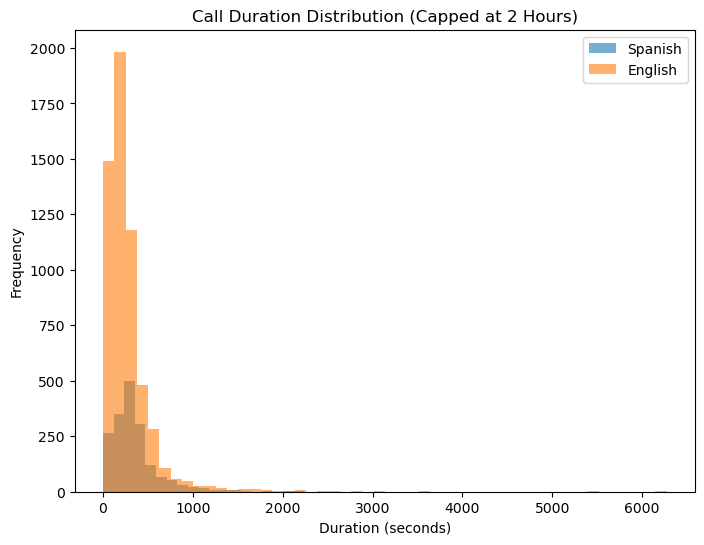

In [105]:
plt.figure(figsize=(8, 6))
plt.hist(spanish_sessions['total_duration'], bins=50, alpha=0.6, label='Spanish')
plt.hist(english_sessions['total_duration'], bins=50, alpha=0.6, label='English')
plt.title('Call Duration Distribution (Capped at 2 Hours)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


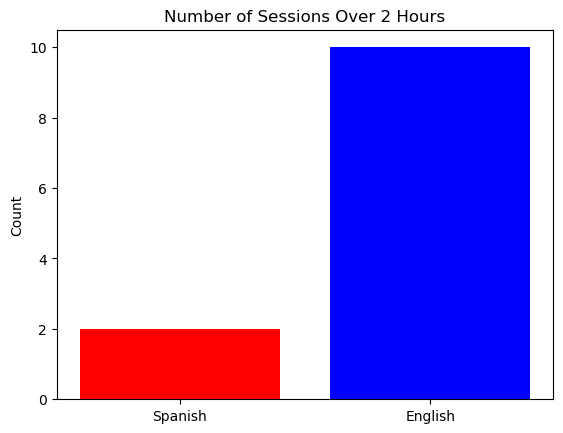

In [107]:
plt.bar(['Spanish', 'English'], [spanish_over2h, english_over2h], color=['red', 'blue'])
plt.title('Number of Sessions Over 2 Hours')
plt.ylabel('Count')
plt.show()
